# Multi-Agent LLM Portfolio Generator

This project builds an end-to-end pipeline of LLM agents that generates personalized ETF investment portfolios based on individual user profiles. The system uses the OpenAI Chat Completions API to coordinate three specialized agents — a market analyst, a risk assessor, and a portfolio constructor — which collaborate to analyze real market data and produce tailored recommendations.

**Pipeline:**
1. Data Collection (ETFs, market data, news sentiment)
2. User Profile Definition
3. Multi-Agent Portfolio Generation
4. Backtesting & Evaluation

---
## Setup & Imports

In [180]:
# Install required packages (run once)
# !pip install openai yfinance pandas numpy matplotlib seaborn

In [2]:
import os
import json
from datetime import datetime, timedelta
from typing import Dict, List, Tuple

# Data & Analysis
import pandas as pd
import numpy as np
import yfinance as yf

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# LLM API
from openai import OpenAI

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [1]:
# API Key Setup
# IMPORTANT: Do NOT hardcode your API key here!
# Set it as an environment variable: export OPENAI_API_KEY='your-key'

# In case you want to add key temporarily
# import os
# os.environ['OPENAI_API_KEY'] = "enter your key here in quotes"

# Test API connection
from openai import OpenAI
client = OpenAI()

response = client.responses.create(
    # Used gpt 5.2 for this assignment, can change the model
    model="gpt-5.2",
    # you can replace this with any prompt you'd like to test
    input="Hi I'm Raabiyaal, how are you?"
)

print(response.output_text)

Hi Raabiyaal — I’m doing well, thanks. How are you today?


---
## Part 1: Data Collection & Preparation

Collecting two years of historical price data for 43 ETFs spanning 11 sectors, along with recent news headlines per ETF for sentiment analysis.

In [184]:
# Define ETF universe

ETF_UNIVERSE = {
    'Technology': ['XLK', 'VGT', 'QQQ', 'SMH'],
    'Healthcare': ['XLV', 'VHT', 'IBB', 'FHLC'],
    'Energy': ['XLE', 'VDE', 'IXC', 'AMLP'],
    'Financial': ['XLF', 'VFH', 'KBE', 'KBWB'],
    'Real Estate': ['VNQ', 'IYR', 'XLRE', 'SCHH'],
    'Consumer': ['XLY', 'VCR', 'XLP'],
    'Industrials': ['XLI', 'VIS', 'IYJ', 'ITA'],
    'Bonds': ['BND', 'AGG', 'TLT', 'SGOV'],
    'International': ['VXUS', 'VEA', 'VWO','BNDX','WTRE'],
    'ESG/Sustainable': ['ESGU', 'ESGV', 'SUSL','TAN'],
    'Artificial Intelligence': ['IYW', 'FTEC', 'IGM']
}

# Flatten to single list
all_etfs = [etf for sector_etfs in ETF_UNIVERSE.values() for etf in sector_etfs]
print(f"Total ETFs to analyze: {len(all_etfs)}")
print(f"Sectors covered: {list(ETF_UNIVERSE.keys())}")

Total ETFs to analyze: 43
Sectors covered: ['Technology', 'Healthcare', 'Energy', 'Financial', 'Real Estate', 'Consumer', 'Industrials', 'Bonds', 'International', 'ESG/Sustainable', 'Artificial Intelligence']


In [185]:
def fetch_etf_data(tickers: List[str], period: str = '2y') -> pd.DataFrame:
    """
    Fetch historical price data for given ETFs.
    
    Args:
        tickers: List of ETF ticker symbols
        period: Time period (e.g., '1y', '2y', '5y')
    
    Returns:
        DataFrame with adjusted close prices
    """
    data = yf.download(tickers, period=period)['Close']
    return data

# Fetch data
price_data = fetch_etf_data(all_etfs)
print(f"Data shape: {price_data.shape}")
print(f"Date range: {price_data.index.min()} to {price_data.index.max()}")
price_data.head()

[*********************100%***********************]  43 of 43 completed

Data shape: (501, 43)
Date range: 2024-03-07 00:00:00 to 2026-03-06 00:00:00


Ticker,AGG,AMLP,BND,BNDX,ESGU,ESGV,FHLC,FTEC,IBB,IGM,...,VXUS,WTRE,XLE,XLF,XLI,XLK,XLP,XLRE,XLV,XLY
Date,,,,,,,,,,,,,,,,,,,,,
2024-03-07,91.236504,39.847797,67.702179,45.141037,110.632401,90.157318,67.350983,155.954666,137.586746,86.885262,...,56.370251,17.157158,41.145512,39.374874,119.135109,103.876091,71.729774,37.074055,141.910736,88.974083
2024-03-08,91.320137,39.541149,67.767288,45.177834,109.870232,89.481720,67.224785,153.410675,137.914963,85.182602,...,56.211151,17.414232,41.290688,39.442841,118.872673,102.331375,71.161682,37.512962,141.649536,88.644691
2024-03-11,91.217926,39.643364,67.739395,45.113426,109.743195,89.236938,67.040352,152.737564,137.964691,84.545349,...,56.023968,17.280933,41.716850,39.510818,118.260338,102.050064,71.549866,37.326199,141.572174,88.403809
2024-03-12,90.985619,39.754101,67.534760,45.113426,110.974411,90.323784,67.302452,155.855682,137.308197,86.447144,...,56.482563,17.214285,41.651287,39.675896,118.785194,104.142586,71.919128,37.232811,142.229950,89.165817
2024-03-13,90.818336,39.813728,67.423141,45.067425,110.778976,90.088768,67.156837,154.281784,137.527039,85.650574,...,56.398335,17.109554,42.316284,39.967205,119.105957,103.017372,72.099030,36.999352,141.678589,88.979004


In [ ]:
def calculate_etf_metrics(price_data: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate key metrics for each ETF.
    
    Metrics to calculate:
    - Total return
    - Historical returns
    - Volatility (std of returns)
    - Sharpe ratio (assuming risk-free rate of 3%)
    - Max drawdown
    - Max Loss
    - Average Daily Return
    - Annual Return
    - Sortino Ratio
    """
    # Assuming risk free rate of 3%
    rf = 0.03

    metrics = {}
    
    # Calculating daily returns for further calculations 
    daily_return = price_data.pct_change().dropna()
    for etf in price_data.columns:
        etf_return = daily_return[etf]
        etf_price = price_data[etf]
        # Total Return
        total_return = (etf_price.iloc[-1]/etf_price.iloc[0] - 1)
        # Volatility
        volatility = etf_return.std()*(252**0.5)
        # Sharpe
        sharpe = ((etf_return.mean()*252)-rf)/volatility
        # Max Drawdown
        cumulative = (1 + etf_return).cumprod()
        peak = cumulative.cummax()
        drawdown = (cumulative - peak) / peak
        max_drawdown = drawdown.min()
        # Max Loss 
        max_loss = etf_return.min()
        # Average Daily Return
        avg_return = etf_return.mean()
        # Annual Return
        annual_return = (1 + etf_return.mean())**252 - 1
        # Sortino Ratio
        negative_return = etf_return[etf_return < 0] 
        negative_volatility = negative_return.std()*(252**0.5)
        sortino = ((etf_return.mean()*252)-rf)/negative_volatility

        metrics[etf] = {"Total Return": total_return,
                        "Volatility": volatility,
                        "Sharpe Ratio": sharpe,
                        "Max Drawdown": max_drawdown,
                        "Max Loss": max_loss,
                        "Average Daily Return": avg_return,
                        "Annual Return": annual_return,
                        "Sortino Ratio":sortino}
  
    return pd.DataFrame(metrics).T

etf_metrics = calculate_etf_metrics(price_data)
etf_metrics.head(40)

,Total Return,Volatility,Sharpe Ratio,Max Drawdown,Max Loss,Average Daily Return,Annual Return,Sortino Ratio
AGG,0.097368,0.047751,0.376353,-0.048220,-0.012668,0.000190,0.049136,0.569717
AMLP,0.320023,0.153832,0.792060,-0.142667,-0.071118,0.000603,0.163925,1.016362
BND,0.096567,0.047157,0.372697,-0.047404,-0.012056,0.000189,0.048721,0.566804
BNDX,0.073081,0.033493,0.182474,-0.023484,-0.008109,0.000143,0.036769,0.275766
ESGU,0.321674,0.163429,0.757956,-0.193245,-0.059150,0.000611,0.166286,0.970619
ESGV,0.293517,0.171673,0.666281,-0.204053,-0.056259,0.000573,0.155278,0.867007
FHLC,0.082241,0.147793,0.140437,-0.168692,-0.054285,0.000201,0.052060,0.196213
FTEC,0.374053,0.254850,0.637346,-0.272991,-0.072326,0.000764,0.212100,0.851832
IBB,0.217850,0.205877,0.439800,-0.248510,-0.057683,0.000478,0.128079,0.628732
IGM,0.414624,0.245605,0.711813,-0.263858,-0.069841,0.000813,0.227208,0.949303


In [187]:
def get_etf_news(tickers: List[str]):
    """
    Get 5-10 news titles for each ETF.
    why do we use titles? 
    1. news summaries/articles are probs blocked by paywall
    2. news titles are v descriptive --> act like good header summaries
    
    Metrics to calculate:
    - Extract news titles from yfinance news output

    Returns:
        Data structure of choice that stores the ETF and corresponding news titles.
    """
    metrics = {}
    
    for ticker in tickers:
        etf = yf.Ticker(ticker)
        news = etf.news
        # print(news[0])
        titles = []
        # print(ticker, len(news))
        for item in news[:10]:
            if 'content' in item and 'title' in item['content']:
                titles.append(item['content']['title'])
        metrics[ticker] = titles  
    return pd.DataFrame.from_dict(metrics, orient="index")


etf_news = get_etf_news(all_etfs)
etf_news.head(10)

,0,1,2,3,4,5,6,7,8,9
XLK,Sector Update: Tech Stocks Fall Late Afternoon,"The structural tailwind behind AI, tech stocks...",Exchange-Traded Funds Move Lower as US Equitie...,"Exchange-Traded Funds, Equity Futures Lower Pr...",Exchange-Traded Funds Drop as US Equities Poin...,"Exchange-Traded Funds, Equity Futures Lower Pr...","Where Should You Put $10,000 Today? Look at Th...",Sector Update: Tech Stocks Rise Late Afternoon,Sector Update: Tech Stocks Advance Wednesday A...,Exchange-Traded Funds Rise as US Equities Move...
VGT,Budget iPhone 17e to Boost Apple Revenues? ETF...,Buy 3 Vanguard Index Funds to Beat the S&P 500...,Daily ETF Flows: VGT On Top,Looking to Buy the Dip on Tech Stocks? Conside...,ETFs to Buy as NVIDIA Shares Gain Following Q4...,"VGT, XLK, or QQQ: Which is the Best Tech ETF t...",Should You Invest in the Vanguard Information ...,"The Smartest Vanguard ETF to Buy With $2,000 R...",Buy 2 Vanguard Index Funds to Beat the S&P 500...,Is Vanguard Information Technology Index Admir...
QQQ,Looking at Invesco QQQ? This ETF Is Probably a...,TQQQ Holders Face a Risk That Has Nothing to D...,Exchange-Traded Funds Move Lower as US Equitie...,Investors in This ETF Have Earned Far More Tha...,Non-Farm Payrolls Sink -92K in February,"Exchange-Traded Funds, Equity Futures Lower Pr...","The Last Time the Fed Chair Was This Hawkish, ...","Forget Tariffs, If Stock Market Crash Occurs U...",U.S. Stock Funds Eke Out February Gain Despite...,"The Zacks Analyst Blog Highlights SPY, DIA, QQ..."
SMH,ETFs to Buy as Broadcom Shares Jump 5% After Q...,The $650 Billion AI Surge Is Here—2 Semiconduc...,When Abundance Becomes Disruption: The AI Spen...,Nvidia Stock Falls Again. Why It’s Still Under...,"MoneyMasters Podcast 2-27-26- Finding Your ""Pe...",Is This the Reason Nvidia Lost 5% Today?,ETFs to Buy as NVIDIA Shares Gain Following Q4...,How to play options amid AI-induced market vol...,AppLovin Surges 11% While Tempus AI and Micron...,ETFs to Buy as NVIDIA Nears $30 Billion Invest...
XLV,Sector Update: Health Care Stocks Softer Late ...,"Exchange-Traded Funds, Equity Futures Lower Pr...","Exchange-Traded Funds, Equity Futures Lower Pr...","Exchange-Traded Funds, Equity Futures Higher P...",Sector Update: Health Care Stocks Decline Late...,"Exchange-Traded Funds, Equity Futures Lower Pr...",Sector Update: Health Care Stocks Retreat Late...,"Stock Market News for Mar 2, 2026","Exchange-Traded Funds, Equity Futures Lower Pr...",Sector Update: Health Care Stocks Advance Late...
VHT,"Exchange-Traded Funds, Equity Futures Lower Pr...","Exchange-Traded Funds, Equity Futures Lower Pr...","Exchange-Traded Funds, Equity Futures Higher P...","Exchange-Traded Funds, Equity Futures Lower Pr...","Exchange-Traded Funds, Equity Futures Lower Pr...","Exchange-Traded Funds, Equity Futures Lower Pr...","Exchange-Traded Funds, Equity Futures Higher P...","Exchange-Traded Funds, Equity Futures Higher P...","Exchange-Traded Funds Mixed, Equity Futures Hi...","Exchange-Traded Funds, Equity Futures Lower Pr..."
IBB,"Exchange-Traded Funds, Equity Futures Lower Pr...","Exchange-Traded Funds, Equity Futures Lower Pr...","Exchange-Traded Funds, Equity Futures Higher P...","Exchange-Traded Funds, Equity Futures Lower Pr...","Exchange-Traded Funds, Equity Futures Lower Pr...","Exchange-Traded Funds, Equity Futures Lower Pr...","Exchange-Traded Funds, Equity Futures Higher P...","Exchange-Traded Funds, Equity Futures Higher P...",Is iShares Biotechnology ETF (IBB) a Strong ET...,"Exchange-Traded Funds Mixed, Equity Futures Hi..."
FHLC,10 Fidelity ETFs With The Lowest Expense Ratio...,Is Fidelity’s Health Care ETF A Good Buy Right...,Should You Invest in the Fidelity MSCI Health ...,UnitedHealth Lifts EPS Outlook Despite Mixed Q...,ETFs to Watch Post JNJ's Q3 Earnings Surprise ...,None,None,None,None,None
XLE,Sector Update: Energy Stocks Mixed Late Afternoon,Sector Update: Energy,Sector Update: Energy Stocks Rise Friday After...,Exchange-Traded Funds Move Lower as

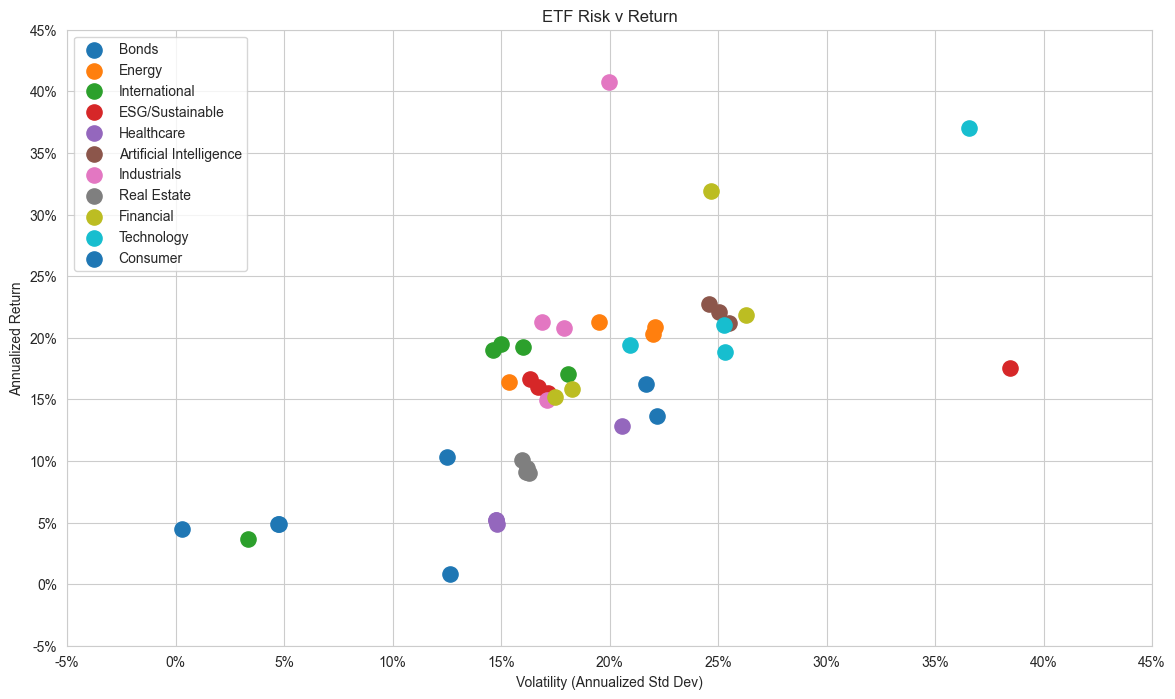

In [188]:
# Visualize ETF characteristics
plt.figure(figsize=(14, 8))

sector_map = {}
for sector, etfs in ETF_UNIVERSE.items():
    for etf in etfs:
        sector_map[etf] = sector

etf_metrics['Sector'] = etf_metrics.index.map(sector_map)
for sector in etf_metrics['Sector'].unique():

    subset = etf_metrics[etf_metrics['Sector'] == sector]

    plt.scatter(
        subset['Volatility'],
        subset['Annual Return'],
        label=sector,
        s=120
    )

plt.title('ETF Risk v Return')
plt.xlabel('Volatility (Annualized Std Dev)')
plt.ylabel('Annualized Return')
plt.xticks(plt.xticks()[0], [f'{x:.0%}' for x in plt.xticks()[0]])
plt.yticks(plt.yticks()[0], [f'{y:.0%}' for y in plt.yticks()[0]])
plt.legend(loc='upper left')
plt.show()

---
## Part 2: User Profile Collection

Defining structured user profiles to test the pipeline across different risk tolerances, investment horizons, and financial goals.

In [189]:
# Define user profile structure
USER_PROFILES = {
    'young_aggressive': {
        'name': 'Alex (Young Professional)',
        'age': 28,
        'investment_amount': 5000,
        'investment_horizon': '30+ years',
        'risk_tolerance': 'aggressive',
        'interests': ['technology', 'innovation', 'growth'],
        'goals': 'long-term wealth accumulation',
        'income_stability': 'high',
        'existing_portfolio': None
    },
    
    'middle_moderate': {
        'name': 'Jamie (Mid-Career)',
        'age': 45,
        'investment_amount': 10000,
        'investment_horizon': '15-20 years',
        'risk_tolerance': 'moderate',
        'interests': ['balanced growth', 'sustainability', 'dividend income'],
        'goals': 'retirement preparation with some growth',
        'income_stability': 'moderate',
        'existing_portfolio': 'some stocks and bonds'
    },

    'near_retirement_conservative': {
        'name': 'Richie (Near Retirement)',
        'age': 60,
        'investment_amount': 200000,
        'investment_horizon': '5-10 years',
        'risk_tolerance': 'conservative',
        'interests': ['income stability', 'bonds', 'dividend stocks'],
        'goals': 'preserve capital and generate steady income',
        'income_stability': 'stable',
        'existing_portfolio': 'diversified portfolio with bonds and blue-chip stocks'
    },

    'student_beginner': {
        'name': 'Raabiyaal (Graduate Student)',
        'age': 24,
        'investment_amount': 200,
        'investment_horizon': '25+ years',
        'risk_tolerance': 'moderate',
        'interests': ['crypto', 'technology', 'low-cost investing'],
        'goals': 'start investing early and build long-term wealth',
        'income_stability': 'low',
        'existing_portfolio': 'small ETF portfolio'
    }
}

# Display profiles
for profile_id, profile in USER_PROFILES.items():
    print(f"\n{'='*60}")
    print(f"Profile: {profile['name']}")
    print(f"{'='*60}")
    for key, value in profile.items():
        if key != 'name':
            print(f"  {key}: {value}")


Profile: Alex (Young Professional)
  age: 28
  investment_amount: 5000
  investment_horizon: 30+ years
  risk_tolerance: aggressive
  interests: ['technology', 'innovation', 'growth']
  goals: long-term wealth accumulation
  income_stability: high
  existing_portfolio: None

Profile: Jamie (Mid-Career)
  age: 45
  investment_amount: 10000
  investment_horizon: 15-20 years
  risk_tolerance: moderate
  interests: ['balanced growth', 'sustainability', 'dividend income']
  goals: retirement preparation with some growth
  income_stability: moderate
  existing_portfolio: some stocks and bonds

Profile: Richie (Near Retirement)
  age: 60
  investment_amount: 200000
  investment_horizon: 5-10 years
  risk_tolerance: conservative
  interests: ['income stability', 'bonds', 'dividend stocks']
  goals: preserve capital and generate steady income
  income_stability: stable
  existing_portfolio: diversified portfolio with bonds and blue-chip stocks

Profile: Raabiyaal (Graduate Student)
  age: 24
 

---
## Part 3: Multi-Agent LLM Pipeline

Building three specialized agents that each handle a distinct role — market analysis, risk assessment, and portfolio construction — and pass their outputs down the chain.

In [190]:
def call_llm(messages: List[Dict], model: str = "gpt-4.1-mini", temperature: float = 0.7) -> str:
    """
    Helper function to call OpenAI API.
    
    Args:
        messages: List of message dicts with 'role' and 'content'
        model: Model name
        temperature: Sampling temperature
    
    Returns:
        Response content as string

        Also look at the parameters used in the API call (model, temperature, max_tokens).
        You can experiment with different models and parameter settings to see how it affects the output. 
    """
    try:
        response = client.chat.completions.create(
            model=model,
            messages=messages,
            temperature=temperature,
            max_completion_tokens=1000
        )
        return response.choices[0].message.content
    except Exception as e:
        print(f"Error calling LLM: {e}")
        return None
    


### Agent 1: Market Analyst

In [191]:
def market_analyst_agent(etf_metrics: pd.DataFrame, sector_data: Dict) -> str:
    """
    Analyzes current market trends and sector performance.
    
    
    Prompt should:
    - Give the agent a clear role as a market analyst
    - Provide relevant market data (top/bottom peroformers, sector trends, news, use the Part 1 functions)
    - Ask for structured output (sector recommendations, utlook)
    - Encourage data-driven analysis
    
    Returns:
        Market analysis report as string
    """

    top_returns = etf_metrics.sort_values('Annual Return', ascending=False).head(5)
    worst_returns = etf_metrics.sort_values('Annual Return').head(5)
    low_vol = etf_metrics.sort_values('Volatility').head(5)
    high_vol = etf_metrics.sort_values('Volatility',ascending=False).head(5)
    
    # Prepare market data summary
    
    
    system_prompt = """
    You are a professional financial analyst.
    Provide data-driven insights about ETF sector performance.
    Use clear and structured analysis.
    """
    
    user_prompt = f"""
    I've shared with you the top 5 etfs in regards to: Annual Return {top_returns}, 
    Worst Returns {worst_returns}, Low Volatility {low_vol}, High Volatility {high_vol}. 
    Analyze which ETFs should an investor with low risk invest in
    """
    
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]

    return call_llm(messages)

# Test the agent
market_analysis = market_analyst_agent(etf_metrics, ETF_UNIVERSE)
print("\n=== MARKET ANALYST OUTPUT ===")
print(market_analysis)


=== MARKET ANALYST OUTPUT ===
Certainly. For an investor with a low risk tolerance, the primary focus should be on ETFs with:

- **Low volatility** (to reduce fluctuations in portfolio value)
- **Stable or positive Sharpe and Sortino ratios** (indicating good risk-adjusted returns)
- **Low maximum drawdowns and losses** (to avoid large capital declines)

### Analysis of Low-Risk ETF Options

#### 1. **Low Volatility ETFs Group**  
- **SGOV (Bonds)**  
  - Volatility: 0.003118 (extremely low)  
  - Sharpe Ratio: -0.00298 (slightly negative but close to zero)  
  - Max Drawdown: -0.00298 (very shallow)  
  - Sortino Ratio: 0.5913 (moderate positive)  
  - Annual Return: 4.45%  
- **BNDX (International Bonds)**  
  - Volatility: 0.0335  
  - Sharpe Ratio: -0.0235 (close to zero)  
  - Max Drawdown: -0.0081  
  - Sortino Ratio: 0.2758 (positive)  
  - Annual Return: 3.68%  
- **BND (Bonds)**  
  - Volatility: 0.0472  
  - Sharpe Ratio: -0.0474 (close to zero)  
  - Max Drawdown: -0.0121  

### Agent 2: Risk Assessment Agent

In [192]:
def risk_assessment_agent(user_profile: Dict) -> str:
    """
    Assesses user risk tolerance and provides allocation guidelines.
    
    
    Prompt should:
    - Position agent as a financial advisor/risk specialist
    - Take user profile as input
    - Output risk assessment and allocation guidelines (% stocks, bonds, etc.)
    - Consider age, horizon, risk tolerance, goals
    
    Returns:
        Risk assessment report as string
    """
    
    

    system_prompt = """
     You are a financial advisor who helps investors understand their risk level
    and suggests simple asset allocation strategies.
    Keep the explanation clear and practical.    
    """
    
    user_prompt = f"""
    Here is an investor profile:

    {user_profile}

    Based on this profile:
    Assess their risk level, Suggest a simple asset allocation (% stocks, % bonds, % other) and 
    Briefly explain why this allocation fits them.
    """
    
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
    
    return call_llm(messages)

# Test the agent, change the user profile to test different outputs
risk_assessment = risk_assessment_agent(USER_PROFILES['young_aggressive'])
risk_assessment2 = risk_assessment_agent(USER_PROFILES['student_beginner'])
print("\n=== RISK ASSESSMENT OUTPUT ===")
print(risk_assessment)
print("\n=== RISK ASSESSMENT OUTPUT 2 ===")
print(risk_assessment2)



=== RISK ASSESSMENT OUTPUT ===
Alex is young (28) with a long investment horizon (30+ years) and a high risk tolerance labeled as "aggressive." Their income is stable, and the goal is long-term wealth accumulation with interest in growth sectors like technology and innovation.

**Risk Level Assessment:**  
Aggressive — comfortable with higher volatility and aiming for higher growth over time.

**Suggested Asset Allocation:**  
- Stocks: 85%  
- Bonds: 10%  
- Other (e.g., alternative investments, cash): 5%

**Explanation:**  
With a long time horizon, Alex can afford to take more risk by heavily investing in stocks, especially those focused on growth sectors like technology and innovation. Stocks offer the best potential for long-term capital appreciation but come with higher short-term volatility. A small allocation to bonds provides some stability and income, helping to reduce portfolio volatility slightly. The "other" category can include alternatives or cash for liquidity or oppor

### Agent 3: Portfolio Construction Agent

In [193]:
def portfolio_construction_agent(
    user_profile: Dict,
    market_analysis: str,
    risk_assessment: str,
    available_etfs: Dict[str, List[str]]
) -> str:
    """
    Creates final portfolio recommendations based on all inputs.
    
    
    Prompt should:
    - Position agent as portfolio manager
    - Synthesize inputs from previous agents
    - Output specific ETF recommendations with allocation %
    - Ensure allocations sum to 100%
    - Consider asking for JSON output for easier parsing
    
    Returns:
        Portfolio recommendations (ideally as JSON string)
    """
    
    
    system_prompt = """
    You are a portfolio manager who builds ETF portfolios for investors.
    Use the investor profile, market analysis, and risk assessment to
    recommend a simple ETF portfolio.
    Ensure allocations add up to 100%.
    """

    user_prompt = f"""
    Investor profile:
    {user_profile}

    Market analysis:
    {market_analysis}

    Risk assessment:
    {risk_assessment}

    Available ETFs by sector:
    {available_etfs}

    Create a portfolio recommendation:
    - Select suitable ETFs
    - Assign allocation percentages
    - Ensure total allocation = 100%

    Return the result as JSON with ETF tickers and allocation percentages.
    """

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]

    return call_llm(messages)

# Test the agent
portfolio_recommendation = portfolio_construction_agent(
    USER_PROFILES['young_aggressive'],
    market_analysis,
    risk_assessment,
    ETF_UNIVERSE
)
print("\n=== PORTFOLIO CONSTRUCTION OUTPUT ===")
print(portfolio_recommendation)


=== PORTFOLIO CONSTRUCTION OUTPUT ===
{
  "QQQ": 40,
  "VGT": 25,
  "IYW": 10,
  "BND": 10,
  "VNQ": 5,
  "SGOV": 5,
  "Cash/Alternatives": 5
}


### Complete Pipeline

In [194]:
def generate_portfolio(user_profile: Dict, etf_metrics: pd.DataFrame) -> Dict:
    """
    Complete pipeline to generate a portfolio for a user.
    """
    print(f"\nGenerating portfolio for: {user_profile['name']}")
    print("="*60)

    # Step 1: Market Analysis
    print("\n[1/3] Running Market Analyst...")
    market_analysis = market_analyst_agent(etf_metrics, ETF_UNIVERSE)

    # Step 2: Risk Assessment
    print("[2/3] Running Risk Assessment...")
    risk_assessment = risk_assessment_agent(user_profile)

    # Step 3: Portfolio Construction
    print("[3/3] Running Portfolio Construction...")
    portfolio = portfolio_construction_agent(
        user_profile, market_analysis, risk_assessment, ETF_UNIVERSE
    )

    print("\n✓ Portfolio generation complete!")

    return {
        'user_profile': user_profile,
        'market_analysis': market_analysis,
        'risk_assessment': risk_assessment,
        'portfolio': portfolio
    }


def display_portfolio_result(result: Dict):
    """Pretty-print a portfolio generation result."""
    profile = result['user_profile']
    sep = "=" * 65

    print(sep)
    print(f"  PORTFOLIO REPORT: {profile['name'].upper()}")
    print(sep)

    # ── Profile summary ──────────────────────────────────────────────
    print("\n📋 INVESTOR PROFILE")
    print("-" * 40)
    fields = [
        ("Age",               profile['age']),
        ("Investment Amount", f"${profile['investment_amount']:,}"),
        ("Horizon",           profile['investment_horizon']),
        ("Risk Tolerance",    profile['risk_tolerance'].capitalize()),
        ("Goals",             profile['goals']),
        ("Interests",         ", ".join(profile['interests'])),
    ]
    for label, value in fields:
        print(f"  {label:<20} {value}")

    # ── Risk assessment ───────────────────────────────────────────────
    print("\n📊 RISK ASSESSMENT")
    print("-" * 40)
    for line in result['risk_assessment'].splitlines():
        print(f"  {line}")

    # ── Portfolio allocation ──────────────────────────────────────────
    print("\n💼 PORTFOLIO ALLOCATION")
    print("-" * 40)
    raw = result['portfolio']
    # Strip markdown code fences if present
    import re
    json_match = re.search(r'```(?:json)?\s*(\{.*?\})\s*```', raw, re.DOTALL)
    if json_match:
        try:
            port_json = json.loads(json_match.group(1))
            # Flatten nested dict if needed
            allocations = {}
            for k, v in port_json.items():
                if isinstance(v, dict):
                    for ticker, pct in v.items():
                        allocations[ticker] = pct
                else:
                    allocations[k] = v
            print(f"  {'ETF/Asset':<30} {'Allocation':>10}")
            print(f"  {'-'*30} {'-'*10}")
            for ticker, pct in allocations.items():
                bar = "█" * int(pct // 5)
                print(f"  {ticker:<30} {str(pct)+'%':>8}  {bar}")
            total = sum(v for v in allocations.values() if isinstance(v, (int, float)))
            print(f"  {'-'*30} {'-'*10}")
            print(f"  {'TOTAL':<30} {str(total)+'%':>8}")
        except Exception:
            print(raw)
    else:
        print(raw)

    print()


# ── Run pipeline on both profiles ────────────────────────────────────
result_alex   = generate_portfolio(USER_PROFILES['young_aggressive'],            etf_metrics)
result_richie = generate_portfolio(USER_PROFILES['near_retirement_conservative'], etf_metrics)

display_portfolio_result(result_alex)
display_portfolio_result(result_richie)



Generating portfolio for: Alex (Young Professional)

[1/3] Running Market Analyst...
[2/3] Running Risk Assessment...
[3/3] Running Portfolio Construction...

✓ Portfolio generation complete!

Generating portfolio for: Richie (Near Retirement)

[1/3] Running Market Analyst...
[2/3] Running Risk Assessment...
[3/3] Running Portfolio Construction...

✓ Portfolio generation complete!

=== FINAL PORTFOLIO RECOMMENDATION ===
{'user_profile': {'name': 'Alex (Young Professional)', 'age': 28, 'investment_amount': 5000, 'investment_horizon': '30+ years', 'risk_tolerance': 'aggressive', 'interests': ['technology', 'innovation', 'growth'], 'goals': 'long-term wealth accumulation', 'income_stability': 'high', 'existing_portfolio': None}, 'market_analysis': 'To identify suitable ETFs for a low-risk investor, we need to focus on metrics that reflect risk-adjusted returns and downside protection, such as:\n\n- **Volatility**: Lower values indicate less price fluctuation.\n- **Sharpe Ratio and Sortin

---
## Project Summary

This notebook built a complete multi-agent LLM pipeline for personalized ETF portfolio generation. Here's a breakdown of what each part accomplished:

**Part 1 – Data Collection & Preparation**  
Pulled 2 years of historical price data for 43 ETFs across 11 sectors (Technology, Healthcare, Energy, Financials, Real Estate, Consumer, Industrials, Bonds, International, ESG, and AI) using `yfinance`. Calculated key performance metrics for each ETF — total return, annualized volatility, Sharpe ratio, Sortino ratio, max drawdown, and average daily return. Also fetched recent news headlines per ETF to enable sentiment-aware recommendations. A risk-return scatter plot visualized how ETFs cluster by sector, confirming the expected pattern: Technology and Industrials in the high-risk/high-return zone, Bonds and Real Estate at the conservative end.

**Part 2 – User Profiles**  
Defined four investor profiles to stress-test the pipeline across different life stages and risk tolerances: Alex (28, aggressive, tech-focused), Jamie (45, moderate, sustainability-oriented), Richie (60, conservative, income-focused), and Raabiyaal (24, moderate, low-cost ETFs). Each profile carries age, investment amount, time horizon, risk tolerance, goals, and existing portfolio context — all fed directly into the agents.

**Part 3 – Multi-Agent Pipeline**  
Three LLM agents each handle a distinct role in the chain:

- **Market Analyst Agent** — receives the ETF metrics dataframe and identifies top/bottom performers, sector trends, and volatility clusters. Outputs a structured market analysis report.
- **Risk Assessment Agent** — takes the user profile and determines a risk level and target asset allocation (% stocks, % bonds, % other), with a plain-language explanation tailored to the investor's situation.
- **Portfolio Construction Agent** — synthesizes the market analysis and risk assessment alongside the full ETF universe to produce a final allocation in JSON format, with per-ticker percentages summing to 100%.

The `generate_portfolio()` function chains all three agents sequentially, passing outputs downstream, and returns a complete result object for each user. The two test runs — Alex (aggressive, 30+ year horizon) and Richie (conservative, near retirement) — produced appropriately contrasting portfolios: Alex's was tech-heavy with growth-oriented equity ETFs, while Richie's leaned heavily on bond ETFs and capital preservation instruments.